# Track 1 · Part 3 — RadioML 2018.01A (24 modulations, 1024-sample windows)
**Team Rover Rangers · MATLAB in Space Hackathon**

Run this after the 21 GB HDF5 download finishes. It never loads the whole file: it reads a balanced subset in contiguous slices.

1. **Check the file** is completely downloaded
2. **Load a subset** (default 400 examples per modulation-SNR pair = 249,600 examples) + class sanity plot
3. **Train** a deeper 1D CNN on raw I/Q with a wall-clock time limit (`MAX_MINUTES`)
4. **Evaluate**: accuracy vs SNR (-20 to +30 dB), 24-class confusion matrix
5. **Longer windows on real dataset signals**: blind offset estimation with 128 vs 1024 samples (validates Part 2)

Needs a GPU session (on CPU it automatically shrinks the subset and runs much slower). Kernel: `radioml` (needs `h5py`).
Outputs: `outputs/rml2018/`. Dataset: RadioML 2018.01A, DeepSig Inc., CC BY-NC-SA 4.0.

In [1]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
import h5py
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn

# ---------------- Config: edit if needed ----------------
H5_PATH     = f"/scratch/{os.environ.get('USER', 'lakariya.p')}/GOLD_XYZ_OSC.0001_1024.hdf5"
OUT_DIR     = "outputs/rml2018"
PER_PAIR    = 400      # examples per (modulation, SNR) pair -> 24*26*400 = 249,600
EPOCHS      = 15
MAX_MINUTES = 10       # training stops after this many minutes (deadline safety)
BATCH, LR, SEED = 256, 1e-3, 42
MAX_CFO     = 0.02

# Corrected class order (the original DeepSig class list is known to be wrong). Verify with the constellation plot.
CLASSES = ["OOK", "4ASK", "8ASK", "BPSK", "QPSK", "8PSK", "16PSK", "32PSK", "16APSK", "32APSK",
           "64APSK", "128APSK", "16QAM", "32QAM", "64QAM", "128QAM", "256QAM", "AM-SSB-WC",
           "AM-SSB-SC", "AM-DSB-WC", "AM-DSB-SC", "FM", "GMSK", "OQPSK"]

os.makedirs(OUT_DIR, exist_ok=True)
rng = np.random.default_rng(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    PER_PAIR, MAX_MINUTES = 100, 15
    print("WARNING: no GPU, using a smaller subset (100 per pair). Launch a GPU session for full results.")
print("device:", device, torch.cuda.get_device_name(0) if device == "cuda" else "")
T0 = time.time()

device: cuda Tesla V100-SXM2-32GB


In [2]:
# 1) Check the download is complete before reading (a partial HDF5 file can't be opened)
EXPECTED_BYTES = 21_449_148_312
size = os.path.getsize(H5_PATH) if os.path.exists(H5_PATH) else 0
print(f"{H5_PATH}: {size/1e9:.2f} GB of {EXPECTED_BYTES/1e9:.2f} GB")
assert size == EXPECTED_BYTES, "Download not finished (or wrong path). Wait for wget to complete, then rerun."
print("file complete")

/scratch/lakariya.p/GOLD_XYZ_OSC.0001_1024.hdf5: 21.45 GB of 21.45 GB
file complete


In [3]:
# ---------------- 1. Load a balanced subset in contiguous slices ----------------
# The file is ordered by modulation, then SNR, in equal blocks. We read the first PER_PAIR rows of each block.
with h5py.File(H5_PATH, "r") as f:
    n_total, n_cls = f["Y"].shape
    z_all = f["Z"][:, 0]                                  # SNR per example (small: ~10 MB)
    snr_levels = np.unique(z_all)
    n_blocks = n_cls * len(snr_levels)
    block = n_total // n_blocks
    take = min(PER_PAIR, block)
    print(f"file: {n_total} examples, {n_cls} classes, {len(snr_levels)} SNRs, block size {block}; reading {take}/block",
          flush=True)
    X = np.empty((n_blocks * take, 2, 1024), np.float32)
    y = np.empty(n_blocks * take, np.int64)
    snr = np.empty(n_blocks * take, np.int64)
    for b in range(n_blocks):
        a = b * block
        xs = f["X"][a:a + take]                           # (take, 1024, 2)
        X[b * take:(b + 1) * take] = np.transpose(xs, (0, 2, 1))
        y[b * take:(b + 1) * take] = np.argmax(f["Y"][a:a + take], axis=1)   # labels from the file, not assumed
        snr[b * take:(b + 1) * take] = z_all[a:a + take]
        if b % 100 == 0: print(f"  block {b}/{n_blocks}  ({time.time()-T0:.0f}s)", flush=True)
del z_all
SNRS = sorted(np.unique(snr).tolist())
counts = np.bincount(y, minlength=n_cls)
print(f"loaded X {X.shape} in {time.time()-T0:.0f}s | per-class counts min {counts.min()} max {counts.max()}", flush=True)

file: 2555904 examples, 24 classes, 26 SNRs, block size 4096; reading 400/block
  block 0/624  (1s)
  block 100/624  (3s)
  block 200/624  (6s)
  block 300/624  (8s)
  block 400/624  (10s)
  block 500/624  (12s)
  block 600/624  (14s)
loaded X (249600, 2, 1024) in 15s | per-class counts min 10400 max 10400


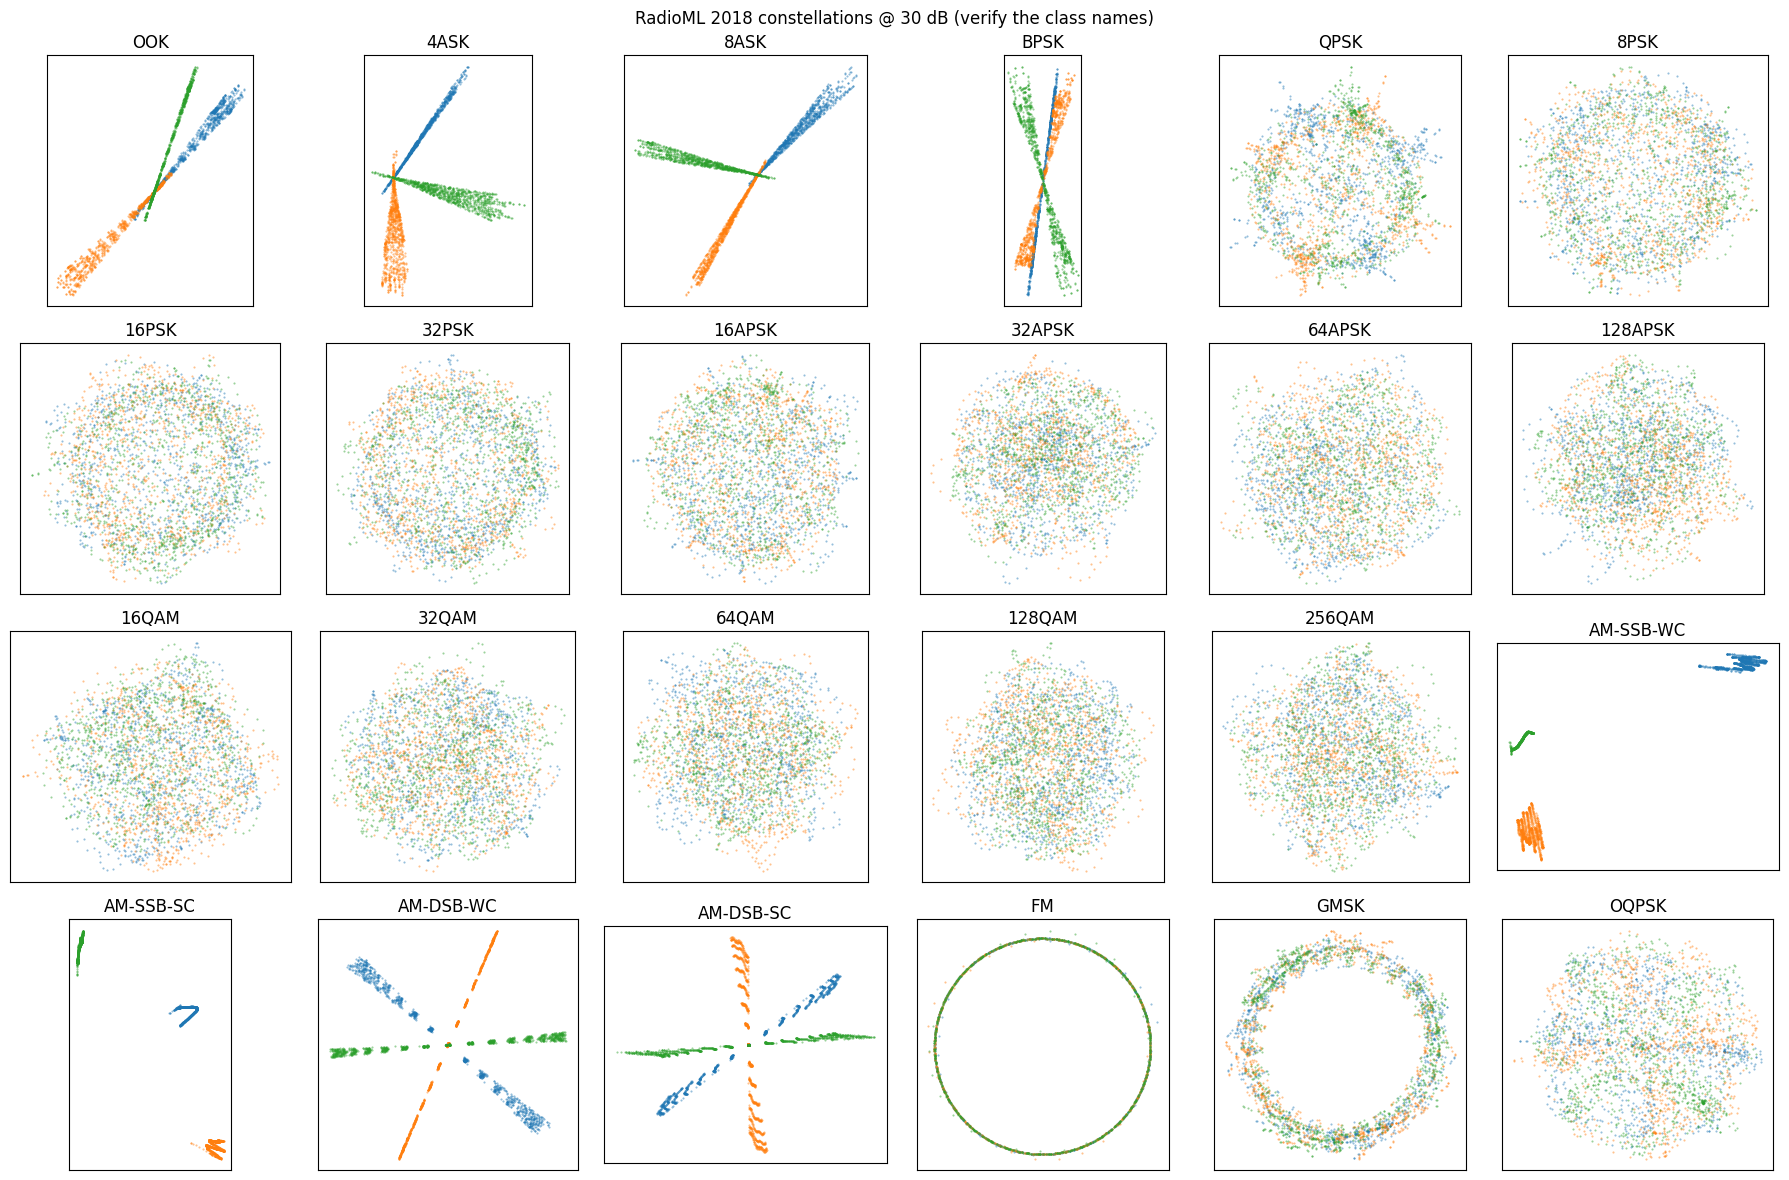

In [4]:
# Sanity plot: constellations at the highest SNR (check the class order!)
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
for c, ax in enumerate(axes.flat):
    idx = np.where((y == c) & (snr == SNRS[-1]))[0][:3]
    for i in idx: ax.plot(X[i, 0], X[i, 1], ".", ms=1, alpha=0.5)
    ax.set_title(CLASSES[c]); ax.set_xticks([]); ax.set_yticks([]); ax.set_aspect("equal")
fig.suptitle(f"RadioML 2018 constellations @ {SNRS[-1]} dB (verify the class names)")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/constellations_2018.png", dpi=120); plt.show()

In [5]:
# ---------------- 2. Split + normalize ----------------
X /= (np.sqrt((X ** 2).sum(axis=1).mean(axis=1))[:, None, None] + 1e-8)
strat = y * 100 + (snr - min(SNRS))
idx = np.arange(len(y))
tr, tmp = train_test_split(idx, test_size=0.30, stratify=strat, random_state=SEED)
va, te = train_test_split(tmp, test_size=0.50, stratify=strat[tmp], random_state=SEED)
print(f"train {len(tr)} val {len(va)} test {len(te)}", flush=True)

train 174720 val 37440 test 37440


In [6]:
# ---------------- 3. Model: deeper 1D CNN for 1024-sample input ----------------
def block_(cin, cout, k, pool=True):
    L = [nn.Conv1d(cin, cout, k, padding=k // 2), nn.BatchNorm1d(cout), nn.ReLU()]
    if pool: L.append(nn.MaxPool1d(2))
    return nn.Sequential(*L)

class IQNet1024(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(block_(2, 64, 7), block_(64, 64, 5), block_(64, 128, 5),
                                      block_(128, 128, 3), block_(128, 128, 3), block_(128, 128, 3, pool=False))
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n_classes))
    def forward(self, x): return self.head(self.features(x))

model = IQNet1024(n_cls).to(device)
print(f"params: {sum(p.numel() for p in model.parameters()):,}", flush=True)

# Keep the training set on the GPU (about 1.4 GB) for speed
Xtr = torch.from_numpy(X[tr]).to(device); ytr = torch.from_numpy(y[tr]).to(device)
use_amp = device == "cuda"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

def predict(x_np, bs=2048):
    model.eval(); out = []
    with torch.no_grad(), torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
        for i in range(0, len(x_np), bs):
            out.append(model(torch.from_numpy(x_np[i:i + bs]).to(device)).argmax(1).cpu())
    return torch.cat(out).numpy()

params: 214,808


In [7]:
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
loss_fn = nn.CrossEntropyLoss()
best, bad, hist, t_train = -1, 0, [], time.time()
for ep in range(1, EPOCHS + 1):
    model.train(); t0, tot = time.time(), 0.0
    perm = torch.randperm(len(tr), device=device)
    for i in range(0, len(tr), BATCH):
        b = perm[i:i + BATCH]
        opt.zero_grad()
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
            loss = loss_fn(model(Xtr[b]), ytr[b])
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        tot += loss.item() * len(b)
    val_acc = float((predict(X[va]) == y[va]).mean())
    sched.step(val_acc)
    hist.append({"epoch": ep, "loss": tot / len(tr), "val_acc": val_acc})
    print(f"ep {ep:2d} loss {tot/len(tr):.4f} val_acc {val_acc:.4f} ({time.time()-t0:.0f}s)", flush=True)
    if val_acc > best:
        best, bad = val_acc, 0; torch.save(model.state_dict(), f"{OUT_DIR}/iqnet1024_best.pt")
    else:
        bad += 1
        if bad >= 3: print("early stop", flush=True); break
    if (time.time() - t_train) / 60 > MAX_MINUTES:
        print(f"time limit {MAX_MINUTES} min reached, stopping", flush=True); break
model.load_state_dict(torch.load(f"{OUT_DIR}/iqnet1024_best.pt", map_location=device))
del Xtr, ytr

ep  1 loss 1.8830 val_acc 0.3605 (11s)
ep  2 loss 1.6421 val_acc 0.4306 (7s)
ep  3 loss 1.5588 val_acc 0.4076 (7s)
ep  4 loss 1.5128 val_acc 0.4603 (7s)
ep  5 loss 1.4721 val_acc 0.4980 (7s)
ep  6 loss 1.4296 val_acc 0.5082 (7s)
ep  7 loss 1.3983 val_acc 0.5194 (7s)
ep  8 loss 1.3727 val_acc 0.5143 (7s)
ep  9 loss 1.3564 val_acc 0.5357 (7s)
ep 10 loss 1.3389 val_acc 0.5236 (7s)
ep 11 loss 1.3237 val_acc 0.5310 (7s)
ep 12 loss 1.3059 val_acc 0.5260 (7s)
early stop


/tmp/ipykernel_2502596/1459628170.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{OUT_DIR}/iqnet1024_best.pt", map_location=device))

test acc overall 0.5352 | SNR >= 10 dB 0.8286


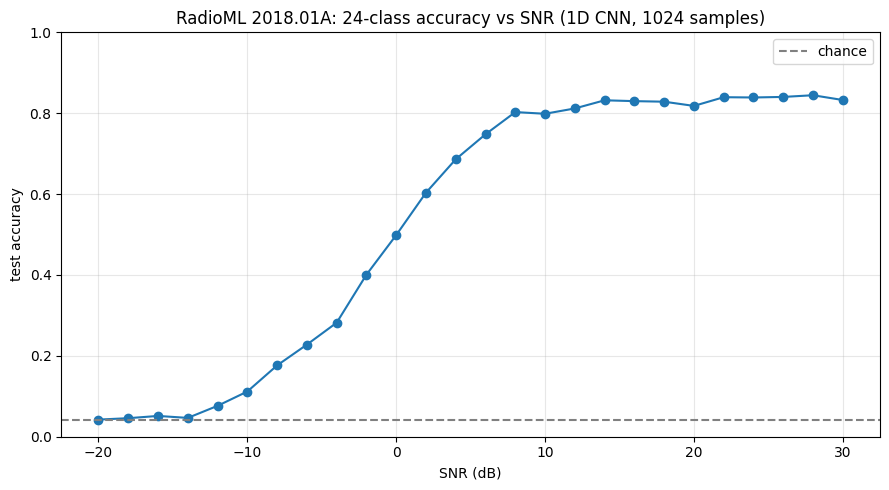

In [8]:
# ---------------- 4. Evaluate ----------------
yp = predict(X[te]); yt, st = y[te], snr[te]
acc_by_snr = {int(s): float((yp[st == s] == yt[st == s]).mean()) for s in SNRS}
hi = st >= 10
overall, acc_hi = float((yp == yt).mean()), float((yp[hi] == yt[hi]).mean())
print(f"test acc overall {overall:.4f} | SNR >= 10 dB {acc_hi:.4f}", flush=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(acc_by_snr), list(acc_by_snr.values()), "o-")
ax.axhline(1 / n_cls, ls="--", c="gray", label="chance")
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("test accuracy"); ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend()
ax.set_title("RadioML 2018.01A: 24-class accuracy vs SNR (1D CNN, 1024 samples)")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/acc_vs_snr_2018.png", dpi=150); plt.show()

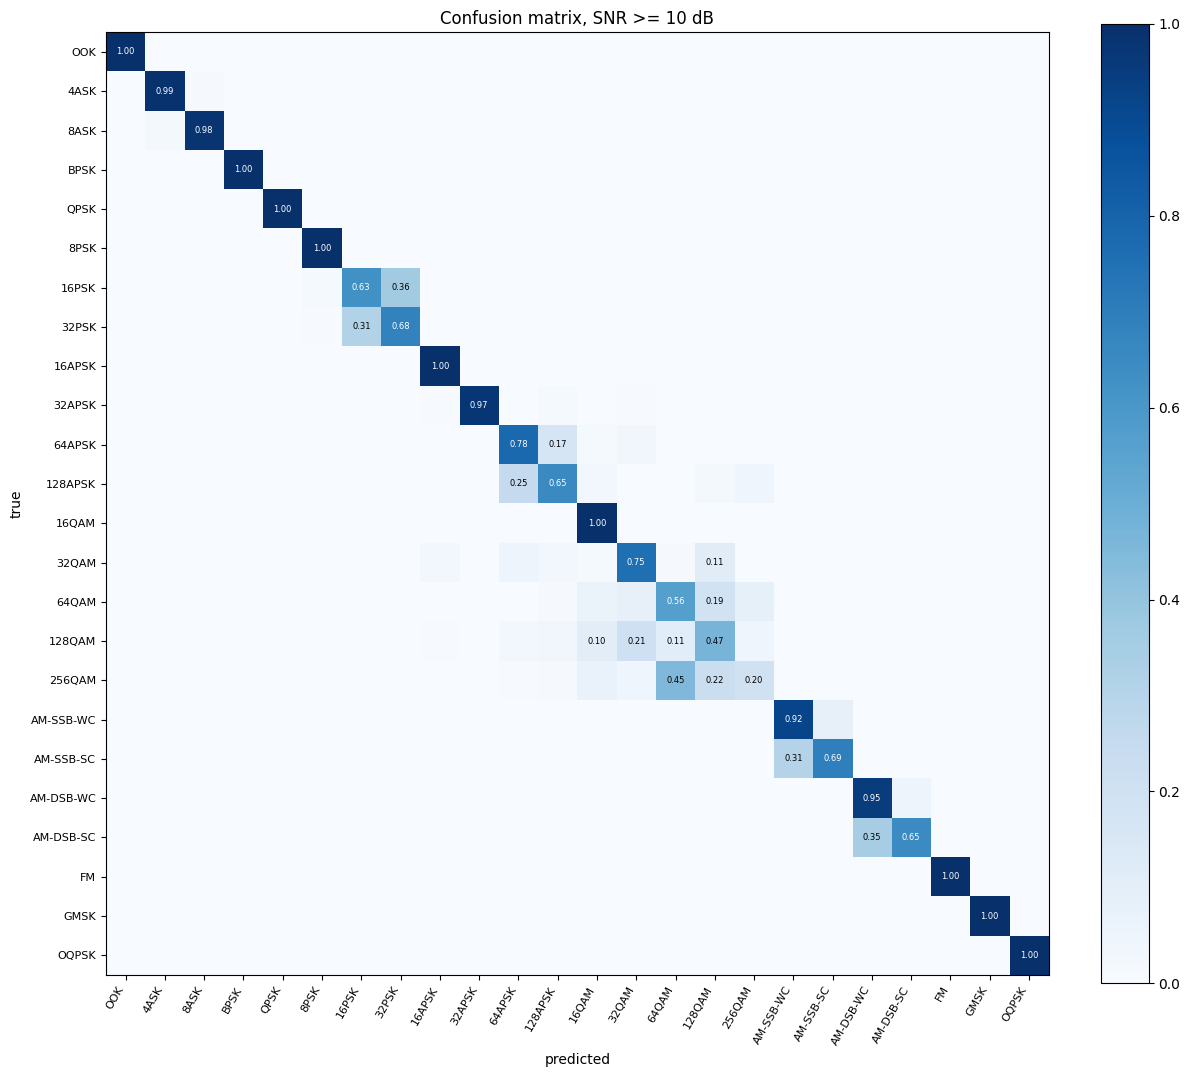

In [9]:
cm = confusion_matrix(yt[hi], yp[hi], labels=range(n_cls), normalize="true")
fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_cls)); ax.set_xticklabels(CLASSES, rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(n_cls)); ax.set_yticklabels(CLASSES, fontsize=8)
for i in range(n_cls):
    for j in range(n_cls):
        if cm[i, j] >= 0.1:
            ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center", fontsize=6,
                    color="white" if cm[i, j] > 0.5 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix, SNR >= 10 dB")
fig.colorbar(im, fraction=0.046); fig.tight_layout()
fig.savefig(f"{OUT_DIR}/cm_2018_snr_ge_10.png", dpi=150); plt.show()

### Longer windows on real dataset signals
Inject a known Doppler offset into test examples and estimate it blindly using only the first 128 samples (as in RadioML 2016) vs all 1024 samples.
Labels come from `CLASSES`, so check the constellation plot first.

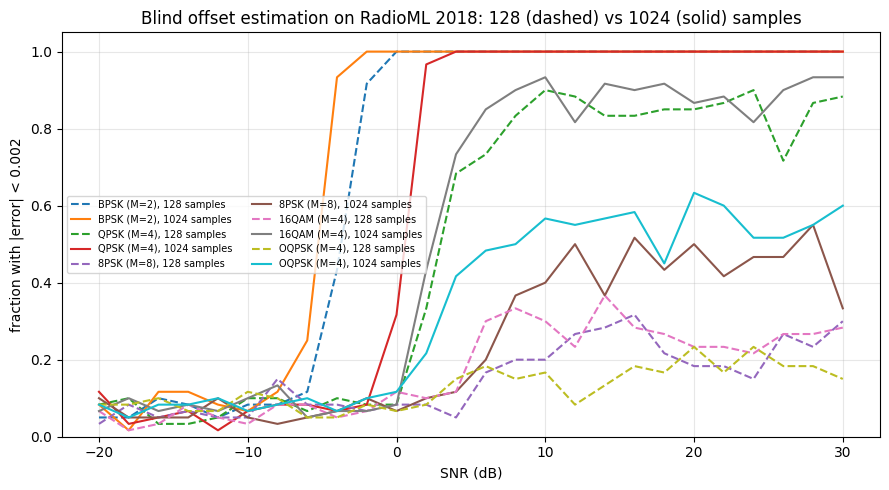

done in 3.4 min -> outputs/rml2018


In [10]:
# ---------------- 5. Longer windows on real dataset signals: 128 vs 1024 samples ----------------
def est_cfo(z, M, fmax=0.03, nfft=4096, chunk=1000):
    fr = np.fft.fftfreq(nfft); keep = np.abs(fr) <= min(M * fmax, 0.5)
    out = np.empty(len(z))
    for i in range(0, len(z), chunk):
        S = np.abs(np.fft.fft(z[i:i + chunk] ** M, nfft, axis=1))[:, keep]
        out[i:i + chunk] = fr[keep][S.argmax(1)] / M
    return out

M_OF = {"BPSK": 2, "QPSK": 4, "8PSK": 8, "16QAM": 4, "OQPSK": 4}
win = {}
fig, ax = plt.subplots(figsize=(9, 5))
for name, M in M_OF.items():
    c = CLASSES.index(name); m = yt == c
    z = X[te][m][:, 0] + 1j * X[te][m][:, 1]
    f = rng.uniform(-MAX_CFO, MAX_CFO, (len(z), 1))
    z = z * np.exp(2j * np.pi * f * np.arange(1024))
    for L, stl in [(128, "--"), (1024, "-")]:
        err = np.abs(est_cfo(z[:, :L], M) - f.ravel())
        ok = [float((err[st[m] == s] < 0.002).mean()) for s in SNRS]
        win[f"{name} L={L}"] = dict(zip(map(int, SNRS), ok))
        ax.plot(SNRS, ok, stl, label=f"{name} (M={M}), {L} samples")
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("fraction with |error| < 0.002")
ax.set_title("Blind offset estimation on RadioML 2018: 128 (dashed) vs 1024 (solid) samples")
ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2); ax.set_ylim(0, 1.05)
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/window_128_vs_1024_2018.png", dpi=150); plt.show()

with open(f"{OUT_DIR}/metrics.json", "w") as fh:
    json.dump({"per_pair": take, "n_examples": int(len(y)), "classes": CLASSES,
               "test_acc_overall": overall, "test_acc_snr_ge_10": acc_hi, "acc_by_snr": acc_by_snr,
               "history": hist, "cfo_window_check": win, "minutes_total": (time.time() - T0) / 60}, fh, indent=2)
print(f"done in {(time.time()-T0)/60:.1f} min -> {OUT_DIR}", flush=True)